#### Brute Force algoritam

In [1]:
import sys
from pathlib import Path
import time

import numpy as np
import pandas as pd

# Root folder projekta
project_root = Path.cwd().parent
sys.path.append(str(project_root))

from algorithms.graph import is_independent
from algorithms.brute_force import brute_force_mis
from algorithms.greedy import greedy_mis
from algorithms.genetic_algorithm import genetic_algorithm
from algorithms.tabu_search import tabu_search

In [2]:
small_dir = project_root / "data" / "small"

small_instances = sorted(small_dir.glob("*.npy"))

print(f"Broj small instanci: {len(small_instances)}")

for path in small_instances:
    print(path.name)

Broj small instanci: 30
small_n10_01.npy
small_n10_02.npy
small_n10_03.npy
small_n10_04.npy
small_n10_05.npy
small_n10_06.npy
small_n10_07.npy
small_n10_08.npy
small_n10_09.npy
small_n10_10.npy
small_n15_01.npy
small_n15_02.npy
small_n15_03.npy
small_n15_04.npy
small_n15_05.npy
small_n15_06.npy
small_n15_07.npy
small_n15_08.npy
small_n15_09.npy
small_n15_10.npy
small_n20_01.npy
small_n20_02.npy
small_n20_03.npy
small_n20_04.npy
small_n20_05.npy
small_n20_06.npy
small_n20_07.npy
small_n20_08.npy
small_n20_09.npy
small_n20_10.npy


In [3]:
brute_force_results = []

for path in small_instances:
    graph = np.load(path)

    start = time.perf_counter()
    solution = brute_force_mis(graph)
    elapsed = time.perf_counter() - start

    brute_force_results.append({
        "Instance": path.stem,
        "n": len(graph),
        "Algorithm": "Brute Force",
        "Solution Size": len(solution),
        "Time (s)": elapsed,
        "Valid": is_independent(graph, solution)
    })

brute_force_results = pd.DataFrame(brute_force_results)

brute_force_results

,Instance,n,Algorithm,Solution Size,Time (s),Valid
0,small_n10_01,10,Brute Force,6,0.000910,True
1,small_n10_02,10,Brute Force,5,0.001110,True
2,small_n10_03,10,Brute Force,5,0.001143,True
3,small_n10_04,10,Brute Force,5,0.001242,True
4,small_n10_05,10,Brute Force,5,0.001528,True
5,small_n10_06,10,Brute Force,4,0.001298,True
6,small_n10_07,10,Brute Force,4,0.001127,True
7,small_n10_08,10,Brute Force,6,0.001056,True
8,small_n10_09,10,Brute Force,6,0.001001,True
9,small_n10_10,10,Brute Force,4,0.001257,True


In [4]:
print("Broj instanci:", len(brute_force_results))
print("Nevalidna rešenja:", (~brute_force_results["Valid"]).sum())
print("Najduže vreme:", brute_force_results["Time (s)"].max())

Broj instanci: 30
Nevalidna rešenja: 0
Najduže vreme: 2.383517990998371


#### Greedy algoritam

In [5]:
greedy_results = []

for path in small_instances:
    graph = np.load(path)

    start = time.perf_counter()
    solution = greedy_mis(graph)
    elapsed = time.perf_counter() - start

    greedy_results.append({
        "Instance": path.stem,
        "n": len(graph),
        "Algorithm": "Greedy",
        "Solution Size": len(solution),
        "Time (s)": elapsed,
        "Valid": is_independent(graph, solution)
    })

greedy_results = pd.DataFrame(greedy_results)

greedy_results

,Instance,n,Algorithm,Solution Size,Time (s),Valid
0,small_n10_01,10,Greedy,6,0.000118,True
1,small_n10_02,10,Greedy,5,0.000060,True
2,small_n10_03,10,Greedy,5,0.000061,True
3,small_n10_04,10,Greedy,5,0.000084,True
4,small_n10_05,10,Greedy,5,0.000067,True
5,small_n10_06,10,Greedy,4,0.000059,True
6,small_n10_07,10,Greedy,4,0.000060,True
7,small_n10_08,10,Greedy,6,0.000087,True
8,small_n10_09,10,Greedy,6,0.000071,True
9,small_n10_10,10,Greedy,4,0.000075,True


In [6]:
print("Broj instanci:", len(greedy_results))
print("Nevalidna rešenja:", (~greedy_results["Valid"]).sum())

Broj instanci: 30
Nevalidna rešenja: 0


#### Genetic algoritam

In [12]:
ga_results = []

for path in small_instances:
    graph = np.load(path)

    start = time.perf_counter()

    solution = genetic_algorithm(
        graph,
        population_size=50,
        max_evaluations=5000,
        crossover_rate=0.6
    )

    elapsed = time.perf_counter() - start

    ga_results.append({
        "Instance": path.stem,
        "n": len(graph),
        "Algorithm": "Genetic Algorithm",
        "Solution Size": len(solution),
        "Time (s)": elapsed,
        "Valid": is_independent(graph, solution)
    })

ga_results = pd.DataFrame(ga_results)

ga_results

,Instance,n,Algorithm,Solution Size,Time (s),Valid
0,small_n10_01,10,Genetic Algorithm,6,0.133482,True
1,small_n10_02,10,Genetic Algorithm,5,0.122587,True
2,small_n10_03,10,Genetic Algorithm,5,0.119809,True
3,small_n10_04,10,Genetic Algorithm,5,0.121727,True
4,small_n10_05,10,Genetic Algorithm,5,0.123127,True
5,small_n10_06,10,Genetic Algorithm,4,0.122495,True
6,small_n10_07,10,Genetic Algorithm,4,0.121527,True
7,small_n10_08,10,Genetic Algorithm,6,0.123723,True
8,small_n10_09,10,Genetic Algorithm,6,0.123318,True
9,small_n10_10,10,Genetic Algorithm,4,0.121788,True


In [13]:
print("Broj instanci:", len(ga_results))
print("Nevalidna rešenja:", (~ga_results["Valid"]).sum())

Broj instanci: 30
Nevalidna rešenja: 0


#### Tabu search algoritam

In [14]:
tabu_results = []

for path in small_instances:
    graph = np.load(path)

    start = time.perf_counter()

    solution = tabu_search(
        graph,
        iterations=100,
        tabu_tenure=5
    )

    elapsed = time.perf_counter() - start

    tabu_results.append({
        "Instance": path.stem,
        "n": len(graph),
        "Algorithm": "Tabu Search",
        "Solution Size": len(solution),
        "Time (s)": elapsed,
        "Valid": is_independent(graph, solution)
    })

tabu_results = pd.DataFrame(tabu_results)

tabu_results

,Instance,n,Algorithm,Solution Size,Time (s),Valid
0,small_n10_01,10,Tabu Search,6,0.001508,True
1,small_n10_02,10,Tabu Search,5,0.000124,True
2,small_n10_03,10,Tabu Search,5,0.000115,True
3,small_n10_04,10,Tabu Search,5,0.000099,True
4,small_n10_05,10,Tabu Search,5,0.000140,True
5,small_n10_06,10,Tabu Search,4,0.001776,True
6,small_n10_07,10,Tabu Search,4,0.002117,True
7,small_n10_08,10,Tabu Search,6,0.001538,True
8,small_n10_09,10,Tabu Search,6,0.001224,True
9,small_n10_10,10,Tabu Search,4,0.000076,True


In [15]:
print("Broj instanci:", len(tabu_results))
print("Nevalidna rešenja:", (~tabu_results["Valid"]).sum())

Broj instanci: 30
Nevalidna rešenja: 0


#### Zbirni rezultati

In [19]:
# Optimalna vrednost za svaku instancu
optimal = brute_force_results[
    ["Instance", "Solution Size"]
].rename(columns={"Solution Size": "Optimal"})

# Spajamo optimum sa rezultatima svih algoritama
all_results = pd.concat([
    brute_force_results,
    greedy_results,
    ga_results,
    tabu_results
], ignore_index=True)

all_results = all_results.merge(
    optimal,
    on="Instance"
)

# Da li je pronađeno optimalno rešenje?
all_results["Optimal Found"] = (
    all_results["Solution Size"] == all_results["Optimal"]
)

summary = (
    all_results
    .groupby("Algorithm")
    .agg(
        **{
            "Vrednost funkcije cilja": ("Solution Size", "mean"),
            "Vreme izvršavanja": ("Time (s)", "mean")
        }
    )
    .reset_index()
)

summary

,Algorithm,Vrednost funkcije cilja,Vreme izvršavanja
0,Brute Force,6.366667,0.758775
1,Genetic Algorithm,5.933333,0.136922
2,Greedy,6.200000,0.000177
3,Tabu Search,6.066667,0.001943


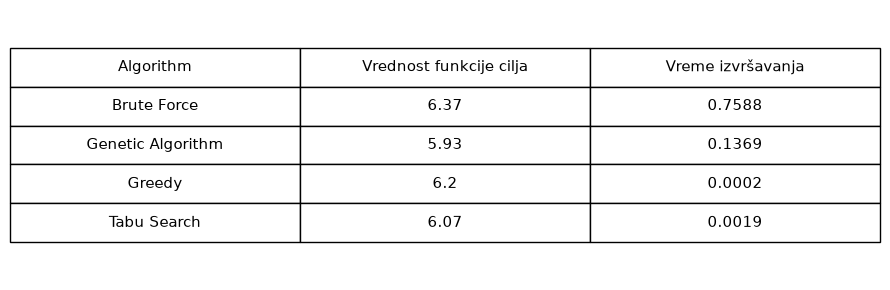

Tabela je sačuvana u: /home/hpdeb/Documents/RI/maximum-independent-set/results/small_summary.png


In [20]:
import matplotlib.pyplot as plt

# Kopija tabele za prikaz
table_data = summary.copy()

# Zaokruživanje
table_data["Vrednost funkcije cilja"] = (
    table_data["Vrednost funkcije cilja"].round(2)
)

table_data["Vreme izvršavanja"] = (
    table_data["Vreme izvršavanja"].round(4)
)

# Kreiranje slike
fig, ax = plt.subplots(figsize=(9, 3))

ax.axis("off")

table = ax.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)

plt.tight_layout()

# Putanja do results foldera
output_path = project_root / "results" / "small_summary.png"

# Čuvanje slike
plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Tabela je sačuvana u: {output_path}")